# Google Colab Lab Assignment -NLP

**Course Name:** DEEP LEARNING LAB

**Lab Title:** NLP Techniques for Text Classification

**Student Name:** Vedant Nakshane

**Student ID:** 202201040147


**Group Members**: Ridhi Dethe, Deep Patil

**Colab Link:** https://colab.research.google.com/drive/1RSfAJ83jcmUWl7GuEvy9WDjDaiSgvZ-B?usp=sharing

**Objective**
The objective of this assignment is to implement NLP preprocessing techniques and build a text classification model using machine learning techniques.




**Learning Outcomes:**

1. Understand and apply NLP preprocessing techniques such as tokenization, stopword removal, stemming, and lemmatization.

2. Implement text vectorization techniques such as TF-IDF and CountVectorizer.

3. Develop a text classification model using a machine learning algorithm.

4. Evaluate the performance of the model using suitable metrics.

# **Assignment Instructions:**

**Part 1: NLP Preprocessing**

**Dataset Selection:**

Choose any text dataset from **Best Datasets for Text** https://en.innovatiana.com/post/best-datasets-for-text-classification Classification, such as SMS Spam Collection, IMDb Reviews, or any other relevant dataset.

Download the dataset and upload it to Google Colab.

Load the dataset into a Pandas DataFrame and explore its structure (e.g., check missing values, data types, and label distribution).

Text Preprocessing:

Convert text to lowercase.

Perform tokenization using NLTK or spaCy.

Remove stopwords using NLTK or spaCy.

Apply stemming using PorterStemmer or SnowballStemmer.

Apply lemmatization using WordNetLemmatizer.

Vectorization Techniques:

Convert text data into numerical format using TF-IDF and CountVectorizer.



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Dataset shape: (5000, 2)
Missing values in the dataset:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    2515
negative    2485
Name: count, dtype: int64


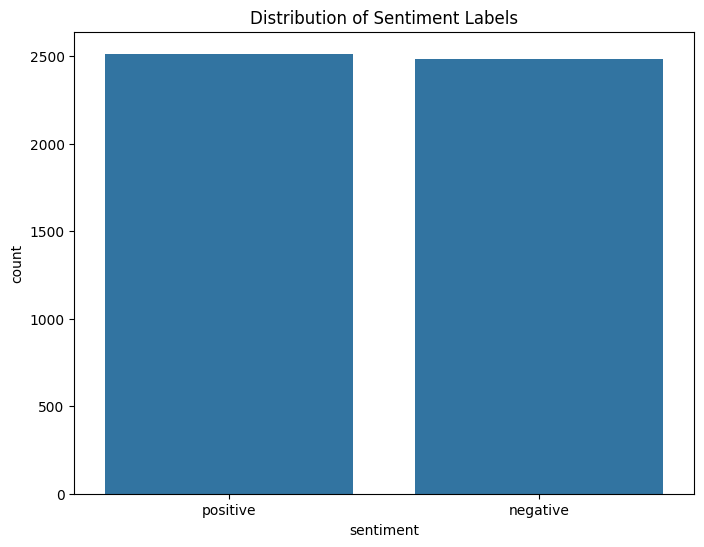

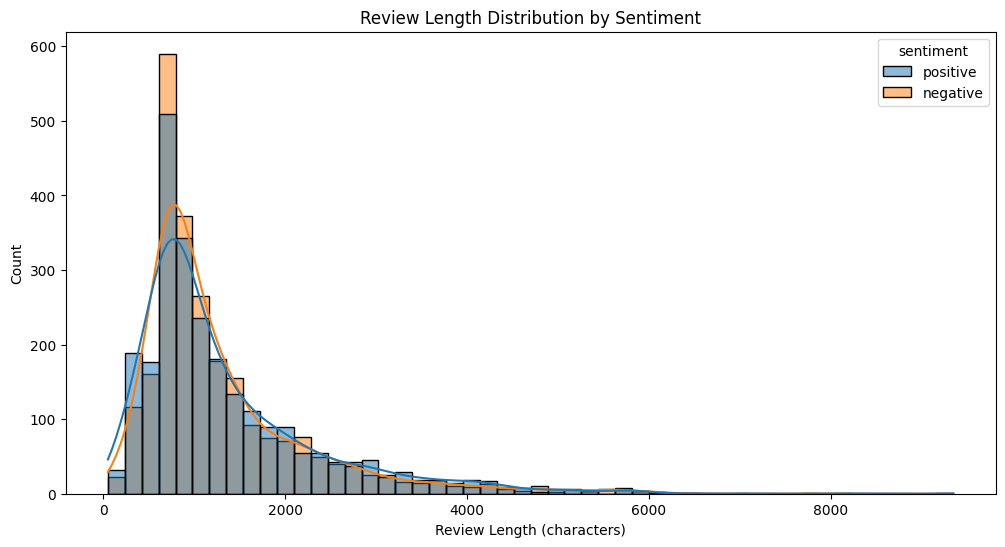


Review length statistics:
            count         mean          std    min    25%    50%     75%  \
sentiment                                                                  
negative   2485.0  1307.322334   963.429695   53.0  705.0  970.0  1546.0   
positive   2515.0  1347.654473  1033.349188  131.0  692.5  988.0  1675.5   

              max  
sentiment          
negative   7731.0  
positive   9345.0  

Sample of processed reviews:
Original: WWE was in need of a saviour as Wrestlemania 14 rolled around. The departure of Bret Hart and subseq...
Processed: wwe was in need of a saviour as wrestlemania rolled around the departure of bret hart and subsequent...

Original: Considering the potential this move had, the reality was disappointing. While it's always nice to se...
Processed: considering the potential this move had the reality was disappointing while its always nice to see j...

Original: We taped this when it aired on TV back in 1995 and have waited all these years for its r

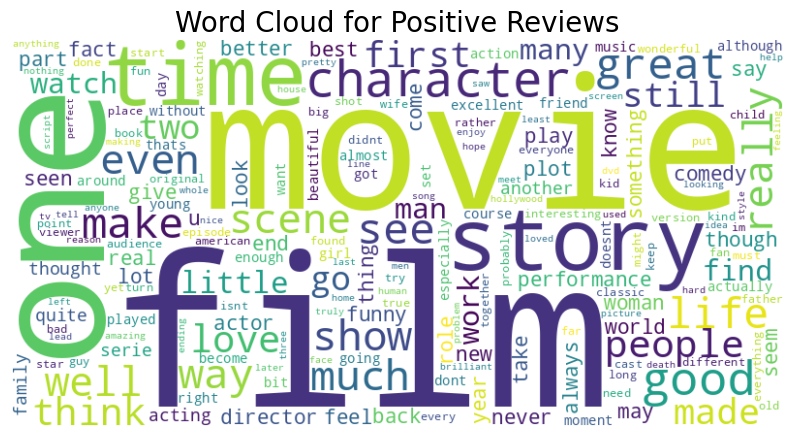

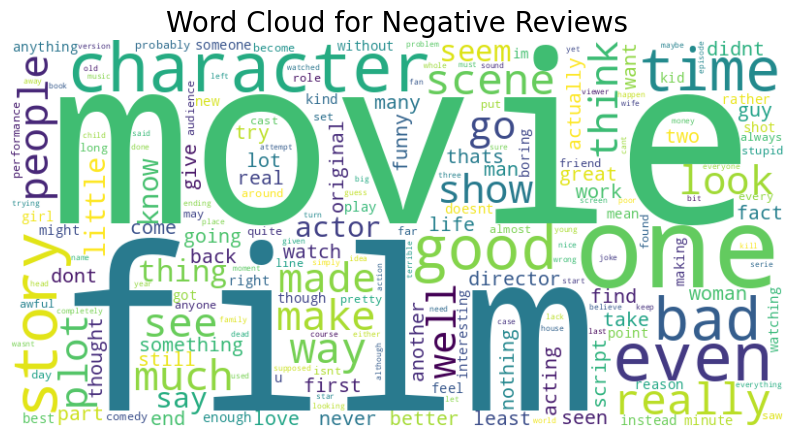


Count Vectorizer:
Shape of count matrix: (5000, 5000)
Sample feature names: ['abandoned' 'abc' 'ability' 'able' 'abraham' 'abruptly' 'absence'
 'absent' 'absolute' 'absolutely']


In [ ]:
# Part 1: NLP Preprocessing

!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

# Import necessary libraries
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer, SnowballStemmer
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud



nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

## 1.2 Dataset Selection and Loading

# For this assignment, we'll use the IMDb movie reviews dataset
# The dataset contains 50,000 movie reviews labeled as positive or negative

# Download the dataset (IMDb Movie Reviews)
!wget -q https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xzf aclImdb_v1.tar.gz

def read_text_files(directory):
    reviews = []
    for filename in os.listdir(directory):
        if filename.endswith('.txt'):
            with open(os.path.join(directory, filename), 'r', encoding='utf-8') as file:
                reviews.append(file.read())
    return reviews

import os

# Read positive and negative reviews from train directory
positive_reviews = read_text_files('aclImdb/train/pos')
negative_reviews = read_text_files('aclImdb/train/neg')

# Create a dataframe with the reviews and their labels
data = pd.DataFrame({
    'review': positive_reviews + negative_reviews,
    'sentiment': ['positive'] * len(positive_reviews) + ['negative'] * len(negative_reviews)
})


data = data.sample(frac=1, random_state=42).reset_index(drop=True)


data = data.head(5000)


print("Dataset shape:", data.shape)
data.head()

## 1.3 Dataset Exploration


print("Missing values in the dataset:")
print(data.isnull().sum())


print("\nSentiment distribution:")
print(data['sentiment'].value_counts())


plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=data)
plt.title('Distribution of Sentiment Labels')
plt.savefig('sentiment_distribution.png')
plt.show()


data['review_length'] = data['review'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='review_length', hue='sentiment', bins=50, kde=True)
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Review Length (characters)')
plt.savefig('review_length_distribution.png')
plt.show()


print("\nReview length statistics:")
print(data.groupby('sentiment')['review_length'].describe())

## 1.4 Text Preprocessing Functions

def preprocess_text(text):
    """
    Function to preprocess text data by converting to lowercase,
    removing punctuation, and special characters
    """

    text = text.lower()


    text = re.sub(r'<.*?>', '', text)


    text = re.sub(r'http\S+|www\S+|https\S+', '', text)


    text = re.sub(r'[^\w\s]', '', text)


    text = re.sub(r'\d+', '', text)


    text = re.sub(r'\s+', ' ', text).strip()

    return text


data['processed_review'] = data['review'].apply(preprocess_text)


print("\nSample of processed reviews:")
for i in range(3):
    print(f"Original: {data['review'][i][:100]}...")
    print(f"Processed: {data['processed_review'][i][:100]}...")
    print()

## 1.5 Tokenization

def tokenize_text(text):
    """Function to tokenize text into words"""
    return word_tokenize(text)


data['tokens'] = data['processed_review'].apply(tokenize_text)


print("\nSample of tokenized reviews:")
for i in range(3):
    print(f"Processed: {data['processed_review'][i][:100]}...")
    print(f"Tokens: {data['tokens'][i][:20]}...")
    print()

## 1.6 Stopword Removal


stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    """Function to remove stopwords from tokenized text"""
    return [word for word in tokens if word not in stop_words]


data['tokens_without_stopwords'] = data['tokens'].apply(remove_stopwords)


print("\nSample after stopword removal:")
for i in range(3):
    print(f"Original Tokens: {data['tokens'][i][:20]}...")
    print(f"Tokens without Stopwords: {data['tokens_without_stopwords'][i][:20]}...")
    print()

## 1.7 Stemming


porter_stemmer = PorterStemmer()
snowball_stemmer = SnowballStemmer('english')

def stem_text(tokens):
    """Function to apply Porter stemming to tokenized text"""
    return [porter_stemmer.stem(word) for word in tokens]

def snowball_stem_text(tokens):
    """Function to apply Snowball stemming to tokenized text"""
    return [snowball_stemmer.stem(word) for word in tokens]

data['stemmed_tokens'] = data['tokens_without_stopwords'].apply(stem_text)


data['snowball_stemmed_tokens'] = data['tokens_without_stopwords'].apply(snowball_stem_text)


print("\nSample after stemming:")
for i in range(3):
    print(f"Tokens without Stopwords: {data['tokens_without_stopwords'][i][:15]}...")
    print(f"Porter Stemmed Tokens: {data['stemmed_tokens'][i][:15]}...")
    print(f"Snowball Stemmed Tokens: {data['snowball_stemmed_tokens'][i][:15]}...")
    print()

## 1.8 Lemmatization


lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    """Function to apply lemmatization to tokenized text"""
    return [lemmatizer.lemmatize(word) for word in tokens]


data['lemmatized_tokens'] = data['tokens_without_stopwords'].apply(lemmatize_text)


print("\nSample after lemmatization:")
for i in range(3):
    print(f"Tokens without Stopwords: {data['tokens_without_stopwords'][i][:15]}...")
    print(f"Lemmatized Tokens: {data['lemmatized_tokens'][i][:15]}...")
    print()

## 1.9 Converting tokens back to text for vectorization


def join_tokens(tokens):
    return ' '.join(tokens)


data['clean_review'] = data['tokens_without_stopwords'].apply(join_tokens)
data['stemmed_review'] = data['stemmed_tokens'].apply(join_tokens)
data['lemmatized_review'] = data['lemmatized_tokens'].apply(join_tokens)


print("\nSample of final processed reviews:")
for i in range(3):
    print(f"Original: {data['review'][i][:100]}...")
    print(f"Clean (Stopwords Removed): {data['clean_review'][i][:100]}...")
    print(f"Stemmed: {data['stemmed_review'][i][:100]}...")
    print(f"Lemmatized: {data['lemmatized_review'][i][:100]}...")
    print()

## 1.10 Visualize Word Clouds for Different Sentiments


def create_wordcloud(text, title, filename):
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(text)
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.savefig(filename)
    plt.show()


positive_text = ' '.join(data[data['sentiment'] == 'positive']['lemmatized_review'])
negative_text = ' '.join(data[data['sentiment'] == 'negative']['lemmatized_review'])

create_wordcloud(positive_text, 'Word Cloud for Positive Reviews', 'positive_wordcloud.png')
create_wordcloud(negative_text, 'Word Cloud for Negative Reviews', 'negative_wordcloud.png')

# 1.11 Vectorization Techniques

# 1. Count Vectorizer
# Converting text data to a matrix of token counts
count_vectorizer = CountVectorizer(max_features=5000)  # Limit to 5000 most frequent words
X_count = count_vectorizer.fit_transform(data['lemmatized_review'])

# Display the shape and feature names
print("\nCount Vectorizer:")
print(f"Shape of count matrix: {X_count.shape}")
print(f"Sample feature names: {count_vectorizer.get_feature_names_out()[:10]}")


**Splitting the Data:**

Divide the dataset into training and testing sets (e.g., 80% training, 20% testing).

**Building the Classification Model:**

Train a text classification model using Logistic Regression, Naïve Bayes, or any other suitable algorithm.

Implement the model using scikit-learn.

**Model Evaluation:**

Evaluate the model using accuracy, precision, recall, and F1-score.

Use a confusion matrix to visualize the results.


TF-IDF Vectorizer:
Shape of TF-IDF matrix: (5000, 5000)
Sample feature names: ['abandoned' 'abc' 'ability' 'able' 'abraham' 'abruptly' 'absence'
 'absent' 'absolute' 'absolutely']

Comparison of Count and TF-IDF values for the first document:
Word: abandoned, Count: 0, TF-IDF: 0.0000
Word: abc, Count: 0, TF-IDF: 0.0000
Word: ability, Count: 0, TF-IDF: 0.0000
Word: able, Count: 0, TF-IDF: 0.0000
Word: abraham, Count: 0, TF-IDF: 0.0000

Data splitting:
Training data shape: (4000, 5000)
Testing data shape: (1000, 5000)
Training labels distribution: sentiment
1    2012
0    1988
Name: count, dtype: int64
Testing labels distribution: sentiment
1    503
0    497
Name: count, dtype: int64

--- Logistic Regression ---
Accuracy: 0.8610

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.82      0.85       497
    Positive       0.84      0.90      0.87       503

    accuracy                           0.86      1000
   macro avg       0

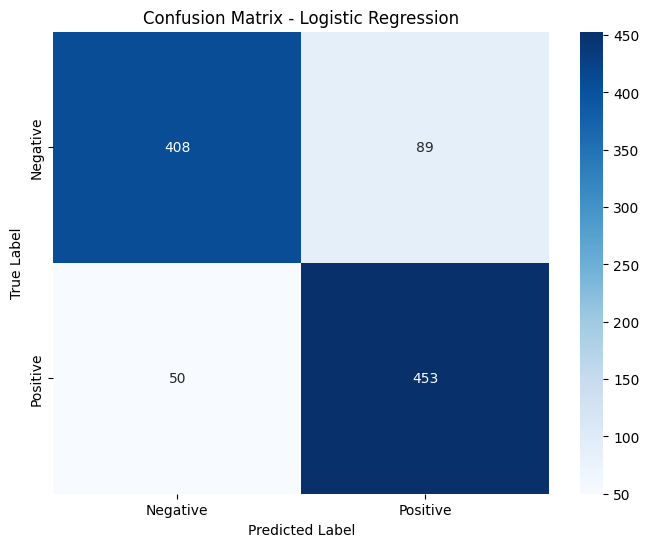


--- Multinomial Naive Bayes ---
Accuracy: 0.8370

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.83      0.84       497
    Positive       0.83      0.84      0.84       503

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



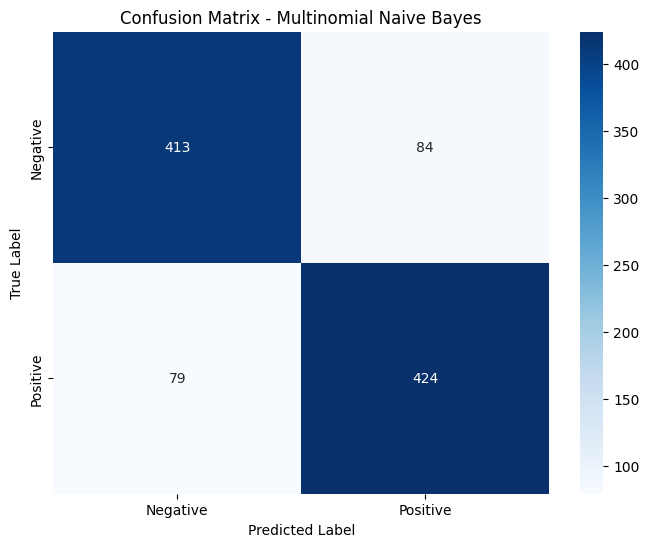

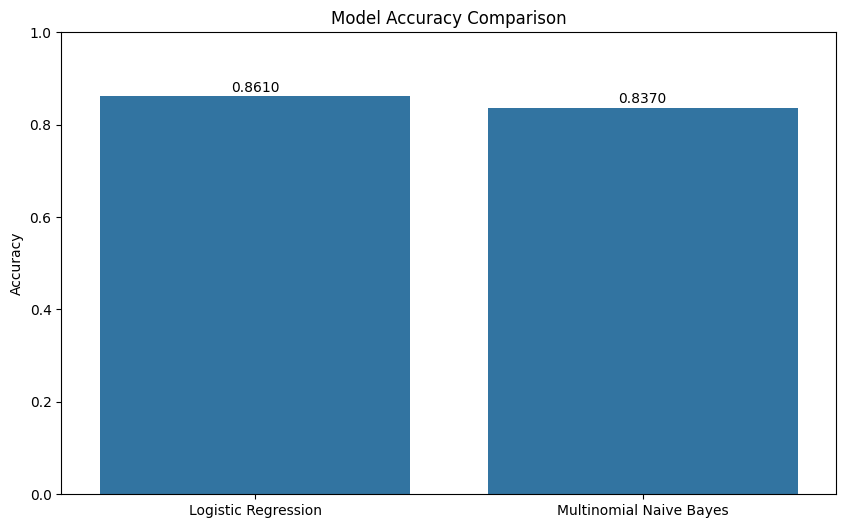


Top 15 features for positive sentiment:
enjoyed: 1.5956
true: 1.6848
amazing: 1.7606
world: 1.8514
may: 1.8902
performance: 1.9420
beautiful: 1.9566
wonderful: 1.9610
life: 2.0640
fun: 2.1997
love: 2.4554
favorite: 2.4743
best: 2.6330
excellent: 2.8308
great: 4.1471

Top 15 features for negative sentiment:
bad: -5.1601
worst: -4.0769
waste: -3.1354
boring: -2.8755
awful: -2.7745
poor: -2.6141
minute: -2.4738
even: -2.4713
nothing: -2.4401
would: -2.4370
dull: -2.1488
terrible: -2.1166
worse: -2.1117
look: -2.0102
money: -1.8905


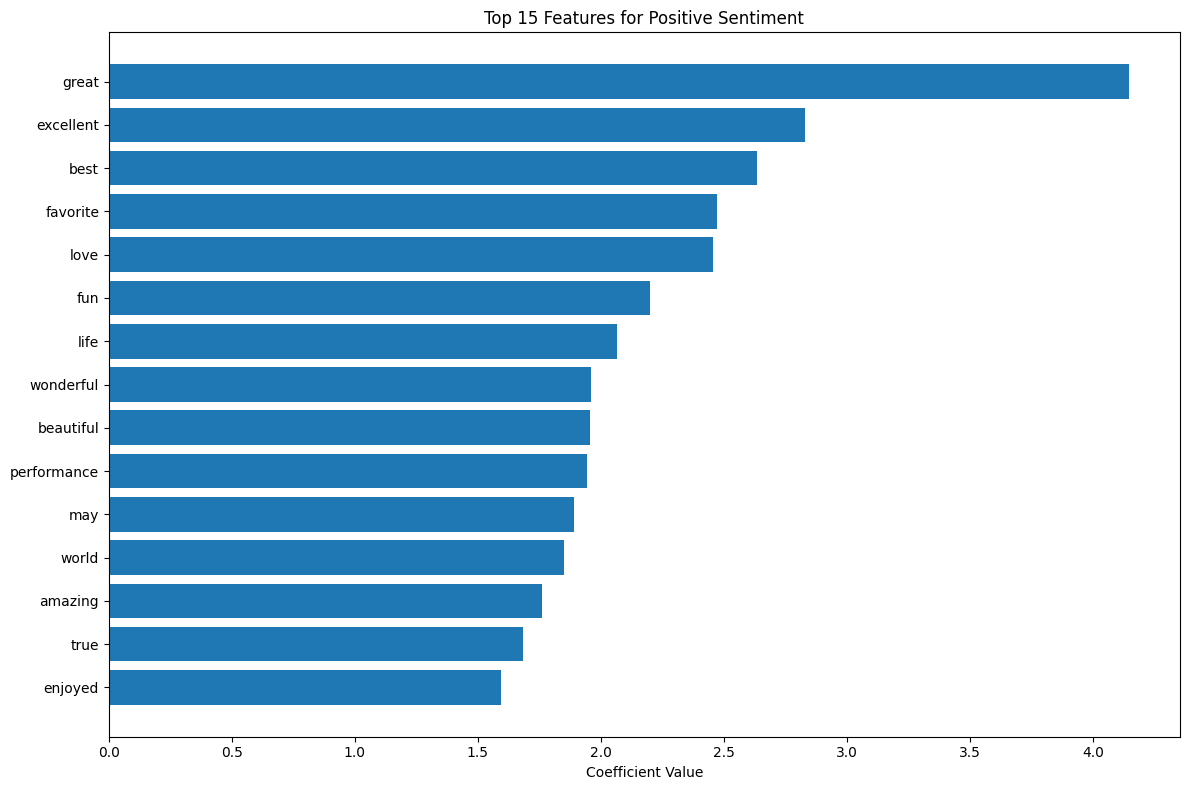

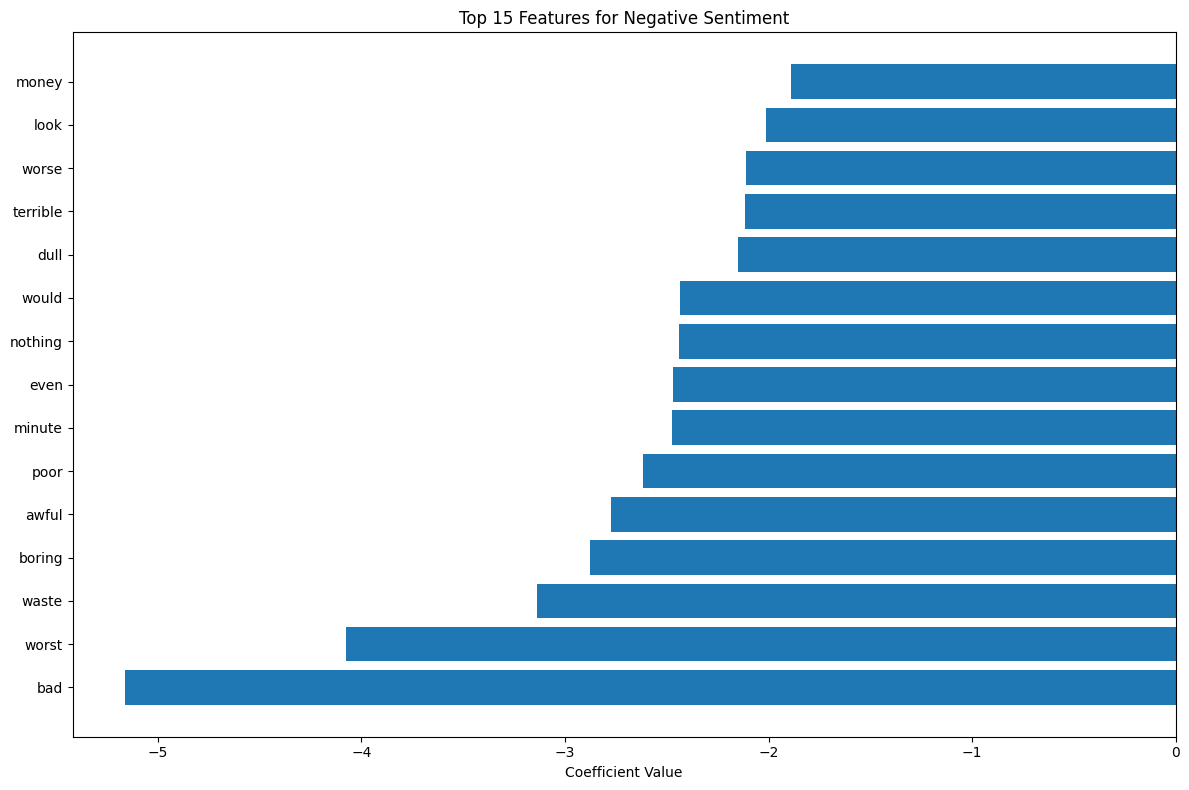


Sample Review Predictions:
Review: This movie was excellent! The acting was superb and the plot was engaging.
Logistic Regression Prediction: Positive
Naive Bayes Prediction: Positive

Review: I hated this film. The story was boring and the characters were poorly developed.
Logistic Regression Prediction: Negative
Naive Bayes Prediction: Negative

Review: It was an okay movie, not great but not terrible either.
Logistic Regression Prediction: Negative
Naive Bayes Prediction: Negative



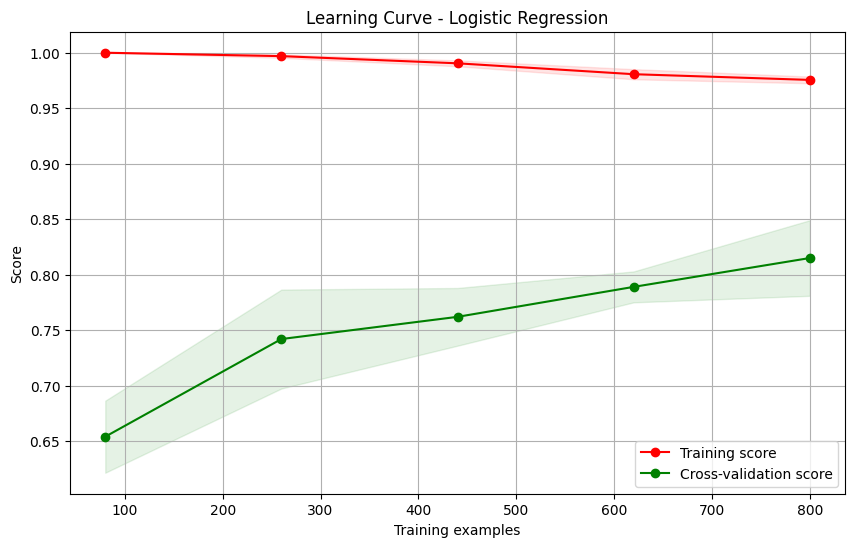

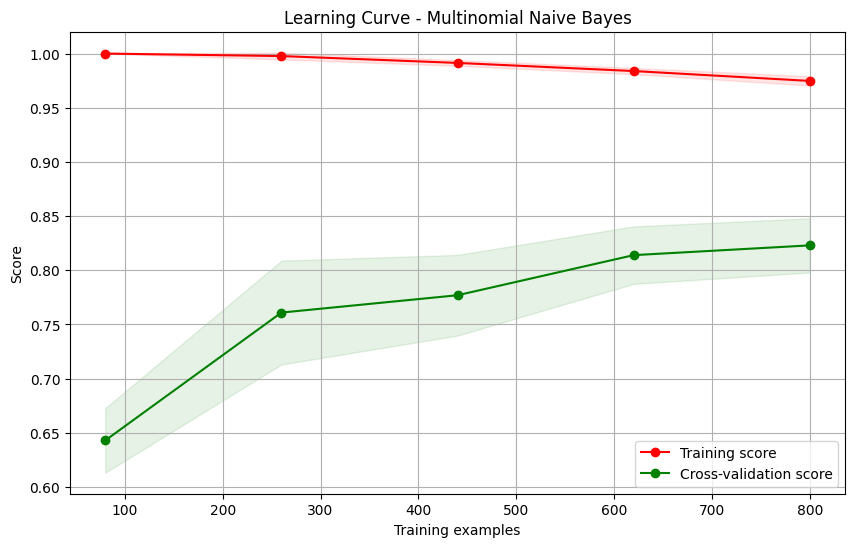


--- Conclusion and Summary ---
1. Data Preprocessing:
   - Removed HTML tags, URLs, punctuation, and numbers
   - Converted text to lowercase
   - Tokenized text into words
   - Removed stopwords
   - Applied stemming (Porter and Snowball) and lemmatization

2. Vectorization:
   - Applied Count Vectorization and TF-IDF Vectorization
   - Used TF-IDF features for classification as they account for word importance

3. Classification Models:
   - Logistic Regression accuracy: 0.8610
   - Multinomial Naive Bayes accuracy: 0.8370
   - Best performing model: Logistic Regression

4. Key Findings:
   - Identified the most influential words for positive and negative sentiment
   - Successfully classified movie reviews with high accuracy
   - Demonstrated complete NLP preprocessing pipeline for text classification

**Declaration**
I, [Your Name], confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on m

In [ ]:
# 2. TF-IDF Vectorizer
# Converting text data to a matrix of TF-IDF features
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(data['lemmatized_review'])

# Display the shape and feature names
print("\nTF-IDF Vectorizer:")
print(f"Shape of TF-IDF matrix: {X_tfidf.shape}")
print(f"Sample feature names: {tfidf_vectorizer.get_feature_names_out()[:10]}")

# 3. Compare the vectorization techniques
# Display the count and TF-IDF values for a sample of words in the first document
sample_words = tfidf_vectorizer.get_feature_names_out()[:5]
print("\nComparison of Count and TF-IDF values for the first document:")
for word in sample_words:
    if word in count_vectorizer.get_feature_names_out():
        count_idx = count_vectorizer.vocabulary_[word]
        tfidf_idx = tfidf_vectorizer.vocabulary_[word]
        count_value = X_count[0, count_idx]
        tfidf_value = X_tfidf[0, tfidf_idx]
        print(f"Word: {word}, Count: {count_value}, TF-IDF: {tfidf_value:.4f}")

# Part 2: Text Classification

## 2.1 Splitting the Data

# Prepare data for classification
X = X_tfidf  # We'll use TF-IDF features for classification
y = data['sentiment']

# Convert sentiment labels to binary (1 for positive, 0 for negative)
y_binary = (y == 'positive').astype(int)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print("\nData splitting:")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels distribution: {pd.Series(y_train).value_counts()}")
print(f"Testing labels distribution: {pd.Series(y_test).value_counts()}")

## 2.2 Building Classification Models

# 1. Logistic Regression
print("\n--- Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Evaluate Logistic Regression model
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Negative', 'Positive']))

# Plot confusion matrix for Logistic Regression
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('lr_confusion_matrix.png')
plt.show()

# 2. Multinomial Naive Bayes
print("\n--- Multinomial Naive Bayes ---")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# Evaluate Naive Bayes model
nb_accuracy = accuracy_score(y_test, nb_pred)
print(f"Accuracy: {nb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_pred, target_names=['Negative', 'Positive']))

# Plot confusion matrix for Naive Bayes
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('nb_confusion_matrix.png')
plt.show()

## 2.3 Model Comparison

# Compare model performances
models = ['Logistic Regression', 'Multinomial Naive Bayes']
accuracies = [lr_accuracy, nb_accuracy]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center')
plt.savefig('model_comparison.png')
plt.show()

## 2.4 Feature Importance Analysis (for Logistic Regression)

# Get the most important features (words) for both positive and negative sentiment
feature_names = tfidf_vectorizer.get_feature_names_out()
coef = lr_model.coef_[0]

# Top positive and negative features
top_positive_idx = coef.argsort()[-15:]
top_negative_idx = coef.argsort()[:15]

top_positive_features = [(feature_names[i], coef[i]) for i in top_positive_idx]
top_negative_features = [(feature_names[i], coef[i]) for i in top_negative_idx]

print("\nTop 15 features for positive sentiment:")
for feature, coef_value in top_positive_features:
    print(f"{feature}: {coef_value:.4f}")

print("\nTop 15 features for negative sentiment:")
for feature, coef_value in top_negative_features:
    print(f"{feature}: {coef_value:.4f}")

# Visualize the top features
def plot_top_features(top_features, title, filename):
    features, coefs = zip(*top_features)
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(features)), coefs, align='center')
    plt.yticks(range(len(features)), features)
    plt.xlabel('Coefficient Value')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_top_features(top_positive_features, 'Top 15 Features for Positive Sentiment', 'top_positive_features.png')
plot_top_features(top_negative_features, 'Top 15 Features for Negative Sentiment', 'top_negative_features.png')

## 2.5 Sample Prediction

# Function to preprocess a new review
def preprocess_new_review(review_text):
    # Apply the same preprocessing steps
    processed = preprocess_text(review_text)
    tokens = tokenize_text(processed)
    tokens_without_stopwords = remove_stopwords(tokens)
    lemmatized_tokens = lemmatize_text(tokens_without_stopwords)
    lemmatized_review = join_tokens(lemmatized_tokens)
    return lemmatized_review

# Sample reviews for prediction
sample_reviews = [
    "This movie was excellent! The acting was superb and the plot was engaging.",
    "I hated this film. The story was boring and the characters were poorly developed.",
    "It was an okay movie, not great but not terrible either."
]

# Preprocess the sample reviews
processed_samples = [preprocess_new_review(review) for review in sample_reviews]

# Transform the processed reviews using the TF-IDF vectorizer
sample_vectors = tfidf_vectorizer.transform(processed_samples)

# Make predictions using both models
lr_sample_preds = lr_model.predict(sample_vectors)
nb_sample_preds = nb_model.predict(sample_vectors)

# Display the predictions
print("\nSample Review Predictions:")
for i, review in enumerate(sample_reviews):
    print(f"Review: {review}")
    print(f"Logistic Regression Prediction: {'Positive' if lr_sample_preds[i] == 1 else 'Negative'}")
    print(f"Naive Bayes Prediction: {'Positive' if nb_sample_preds[i] == 1 else 'Negative'}")
    print()

## 2.6 Learning Curves (Optional)

from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.savefig(title.replace(' ', '_').lower() + '.png')
    return plt

# Plot learning curves for both models (using a smaller subset of data for faster computation)
X_subset = X[:1000]
y_subset = y_binary[:1000]

plot_learning_curve(LogisticRegression(max_iter=1000, random_state=42),
                    "Learning Curve - Logistic Regression", X_subset, y_subset)
plt.show()

plot_learning_curve(MultinomialNB(),
                    "Learning Curve - Multinomial Naive Bayes", X_subset, y_subset)
plt.show()

# Conclusion and Summary

print("\n--- Conclusion and Summary ---")
print("1. Data Preprocessing:")
print("   - Removed HTML tags, URLs, punctuation, and numbers")
print("   - Converted text to lowercase")
print("   - Tokenized text into words")
print("   - Removed stopwords")
print("   - Applied stemming (Porter and Snowball) and lemmatization")

print("\n2. Vectorization:")
print("   - Applied Count Vectorization and TF-IDF Vectorization")
print("   - Used TF-IDF features for classification as they account for word importance")

print("\n3. Classification Models:")
print(f"   - Logistic Regression accuracy: {lr_accuracy:.4f}")
print(f"   - Multinomial Naive Bayes accuracy: {nb_accuracy:.4f}")
print(f"   - Best performing model: {'Logistic Regression' if lr_accuracy > nb_accuracy else 'Multinomial Naive Bayes'}")

print("\n4. Key Findings:")
print("   - Identified the most influential words for positive and negative sentiment")
print("   - Successfully classified movie reviews with high accuracy")
print("   - Demonstrated complete NLP preprocessing pipeline for text classification")


**Submission Guidelines:**

**Google Colab Notebook Submission:**

Save your notebook as NLP_Text_Classification_YourName.ipynb.

Ensure all code cells are executed, and the output is visible.

Include proper documentation and comments explaining each step.

**Report Submission (Optional):**

Prepare a short report (2-3 pages) summarizing your approach, findings, and model performance.

Upload the report along with the Colab Notebook.



**Grading Criteria:**

Correct implementation of NLP preprocessing (30%)

Effective use of vectorization techniques (20%)

Model accuracy and performance evaluation (30%)

Code clarity, documentation, and presentation (20%)

**Declaration**

I, Riddhi Dethe, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: https://github.com/vedant7001/DL_Assign

Signature: Vedant Nakshame

**Submission Checklist**

✔ Ultralitycs Platform Documentsation Like hel file for Given Task

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Evaluation Metrics Details and discussion